In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("accepted.csv", low_memory=False)   # replace with your filename

# Keep only useful columns
keep_cols = [
    "loan_amnt",
    "term",
    "int_rate",
    "installment",
    "grade",
    "sub_grade",
    "emp_length",
    "home_ownership",
    "annual_inc",
    "verification_status",
    "purpose",
    "dti",
    "fico_range_low",
    "fico_range_high",
    "loan_status"
]

df = df[keep_cols]

# Clean 'loan_status' to binary target
df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off', 'Default'])]  # keep only these
df['loan_status'] = df['loan_status'].replace(
    {'Fully Paid': 0, 'Charged Off': 1, 'Default': 1}
)

# Convert term from "36 months" -> 36
df['term'] = df['term'].str.extract('(\d+)').astype(float)



print("Cleaned dataset shape:", df.shape)
print(df.head())

<>:34: SyntaxWarning: invalid escape sequence '\d'
<>:34: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-4031968689.py:34: SyntaxWarning: invalid escape sequence '\d'
  df['term'] = df['term'].str.extract('(\d+)').astype(float)
/tmp/ipython-input-4031968689.py:29: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['loan_status'] = df['loan_status'].replace(


Cleaned dataset shape: (80575, 15)
   loan_amnt  term  int_rate  installment grade sub_grade emp_length  \
0     3600.0  36.0     13.99       123.03     C        C4  10+ years   
1    24700.0  36.0     11.99       820.28     C        C1  10+ years   
2    20000.0  60.0     10.78       432.66     B        B4  10+ years   
4    10400.0  60.0     22.45       289.91     F        F1    3 years   
5    11950.0  36.0     13.44       405.18     C        C3    4 years   

  home_ownership  annual_inc verification_status             purpose    dti  \
0       MORTGAGE     55000.0        Not Verified  debt_consolidation   5.91   
1       MORTGAGE     65000.0        Not Verified      small_business  16.06   
2       MORTGAGE     63000.0        Not Verified    home_improvement  10.78   
4       MORTGAGE    104433.0     Source Verified      major_purchase  25.37   
5           RENT     34000.0     Source Verified  debt_consolidation  10.20   

   fico_range_low  fico_range_high  loan_status  
0      

In [ ]:
import pandas as pd

# This is your friend's starting code
# ------------------------------------
# Load dataset
df = pd.read_csv("accepted.csv", low_memory=False)

# Keep only useful columns
keep_cols = [
    "loan_amnt", "term", "int_rate", "installment", "grade", "sub_grade",
    "emp_length", "home_ownership", "annual_inc", "verification_status",
    "purpose", "dti", "fico_range_low", "fico_range_high", "loan_status"
]
df = df[keep_cols]

# Clean 'loan_status' to binary target
df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off', 'Default'])]
df['loan_status'] = df['loan_status'].replace(
    {'Fully Paid': 0, 'Charged Off': 1, 'Default': 1}
)

# Convert term from "36 months" -> 36
df['term'] = df['term'].str.extract('(\d+)').astype(float)

print("--- Initial Cleaning Complete ---")
print("Cleaned dataset shape:", df.shape)
print("\n")


# My Preprocessing Steps Start Here
# ---------------------------------

print("--- Starting Further Preprocessing ---")

# Step 1: Clean Remaining Text-Based Numerical Columns

# Clean 'int_rate' by removing '%' and converting to float
#df['int_rate'] = df['int_rate'].str.replace('%', '').astype(float)

# Clean 'emp_length' by converting to a numerical scale
# We'll map values like '< 1 year' to 0 and '10+ years' to 10
emp_length_map = {
    '< 1 year': 0.0, '1 year': 1.0, '2 years': 2.0, '3 years': 3.0, '4 years': 4.0,
    '5 years': 5.0, '6 years': 6.0, '7 years': 7.0, '8 years': 8.0, '9 years': 9.0,
    '10+ years': 10.0
}
df['emp_length'] = df['emp_length'].map(emp_length_map)

print("Cleaned 'int_rate' and 'emp_length' columns.")


# Step 2: Handle Missing Values
# Check for missing values in the remaining columns
print("\nMissing values before handling:")
print(df.isnull().sum())

# Given the large size of the dataset, the simplest and most effective
# strategy is to drop rows with any missing values.
df.dropna(inplace=True)

print("\nMissing values handled. New shape:", df.shape)


# Step 3: Feature Engineering (Optional but Recommended)
# Create a single 'fico_score' from the FICO range
df['fico_score'] = (df['fico_range_low'] + df['fico_range_high']) / 2
# We can now drop the original FICO columns
df.drop(['fico_range_low', 'fico_range_high'], axis=1, inplace=True)
print("Created 'fico_score' feature.")


# Step 4: Convert Categorical Features to Numerical (One-Hot Encoding)
# Machine learning models require all input to be numerical.
# We will convert columns like 'grade', 'purpose', etc., into dummy variables.

categorical_cols = df.select_dtypes(include=['object']).columns
print(f"\nCategorical columns to be encoded: {list(categorical_cols)}")

df_processed = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("One-Hot Encoding complete.")


# --- Preprocessing Finished ---
print("\n--- Final Processed Data ---")
print("Final Shape:", df_processed.shape)
print("\nData Types:")
print(df_processed.info())
print("\nFirst 5 rows of the fully processed data:")
print(df_processed.head())

<>:23: SyntaxWarning: invalid escape sequence '\d'
<>:23: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-3608277694.py:23: SyntaxWarning: invalid escape sequence '\d'
  df['term'] = df['term'].str.extract('(\d+)').astype(float)
/tmp/ipython-input-3608277694.py:18: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['loan_status'] = df['loan_status'].replace(


--- Initial Cleaning Complete ---
Cleaned dataset shape: (80575, 15)


--- Starting Further Preprocessing ---
Cleaned 'int_rate' and 'emp_length' columns.

Missing values before handling:
loan_amnt                 0
term                      0
int_rate                  0
installment               0
grade                     0
sub_grade                 0
emp_length             5179
home_ownership            0
annual_inc                0
verification_status       0
purpose                   0
dti                       2
fico_range_low            0
fico_range_high           0
loan_status               0
dtype: int64

Missing values handled. New shape: (75396, 15)
Created 'fico_score' feature.

Categorical columns to be encoded: ['grade', 'sub_grade', 'home_ownership', 'verification_status', 'purpose']
One-Hot Encoding complete.

--- Final Processed Data ---
Final Shape: (75396, 65)

Data Types:
<class 'pandas.core.frame.DataFrame'>
Index: 75396 entries, 0 to 91680
Data columns (total 65 c

Libraries imported successfully.


/tmp/ipython-input-1120422726.py:18: DtypeWarning: Columns (19,59) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('accepted.csv', parse_dates=['issue_d'])
/tmp/ipython-input-1120422726.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv('accepted.csv', parse_dates=['issue_d'])


Dataset loaded successfully with 91681 rows and 151 columns.

## First 5 Rows of the Dataset ##
         id  member_id  loan_amnt  funded_amnt  funded_amnt_inv        term  \
0  68407277        NaN     3600.0       3600.0           3600.0   36 months   
1  68355089        NaN    24700.0      24700.0          24700.0   36 months   
2  68341763        NaN    20000.0      20000.0          20000.0   60 months   
3  66310712        NaN    35000.0      35000.0          35000.0   60 months   
4  68476807        NaN    10400.0      10400.0          10400.0   60 months   

   int_rate  installment grade sub_grade  ... hardship_payoff_balance_amount  \
0     13.99       123.03     C        C4  ...                            NaN   
1     11.99       820.28     C        C1  ...                            NaN   
2     10.78       432.66     B        B4  ...                            NaN   
3     14.85       829.90     C        C5  ...                            NaN   
4     22.45       289.91     

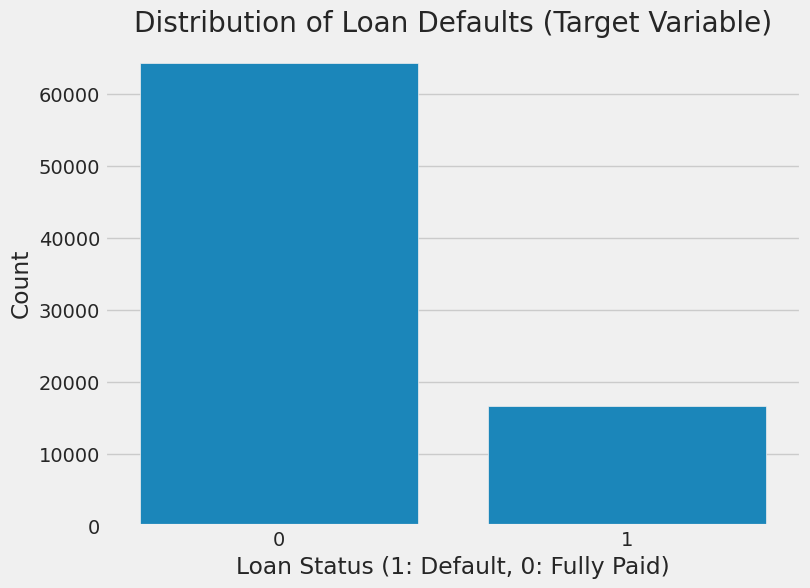

EDA Finding: There is a significant class imbalance. 'Fully Paid' loans far outnumber 'Default' loans.


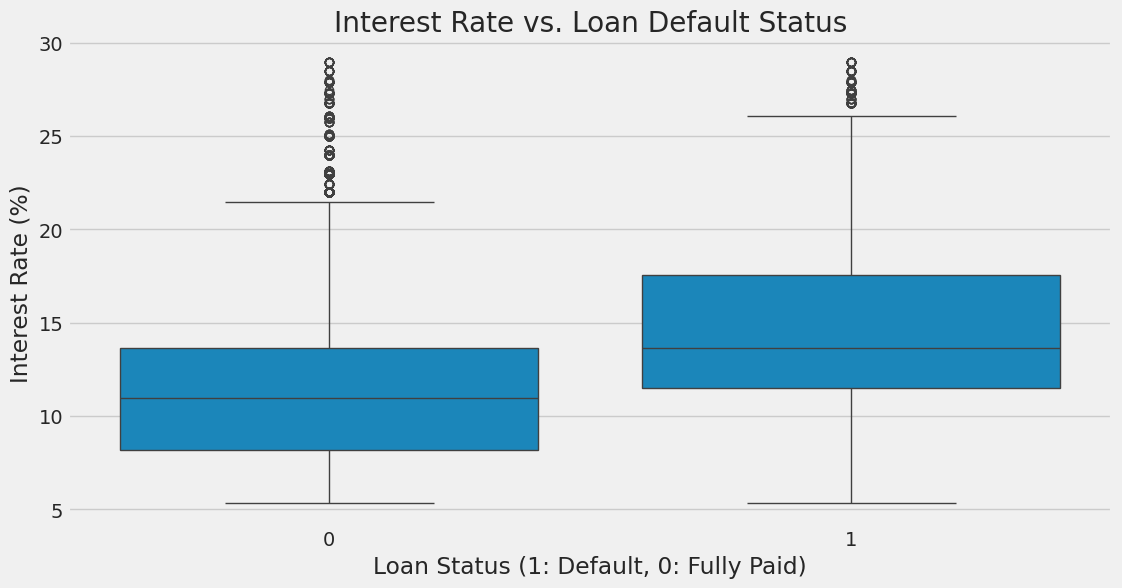

EDA Finding: Yes, loans that defaulted tend to have a higher interest rate.


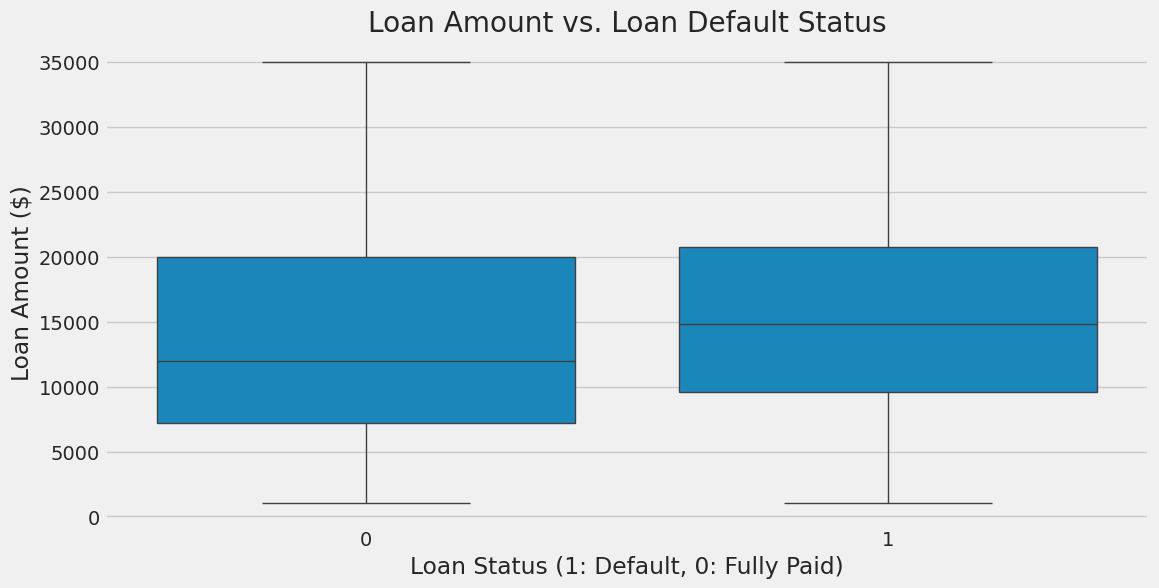

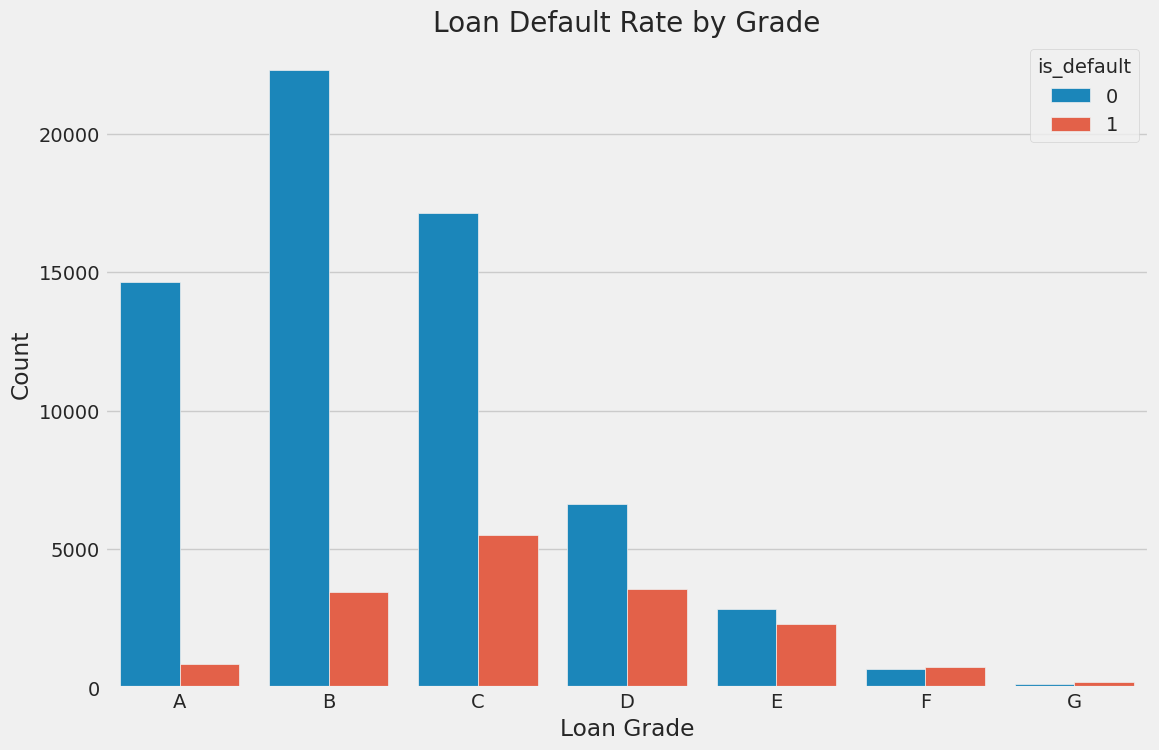

EDA Finding: Lower grades (D, E, F, G) have a much higher proportion of defaults compared to higher grades (A, B).


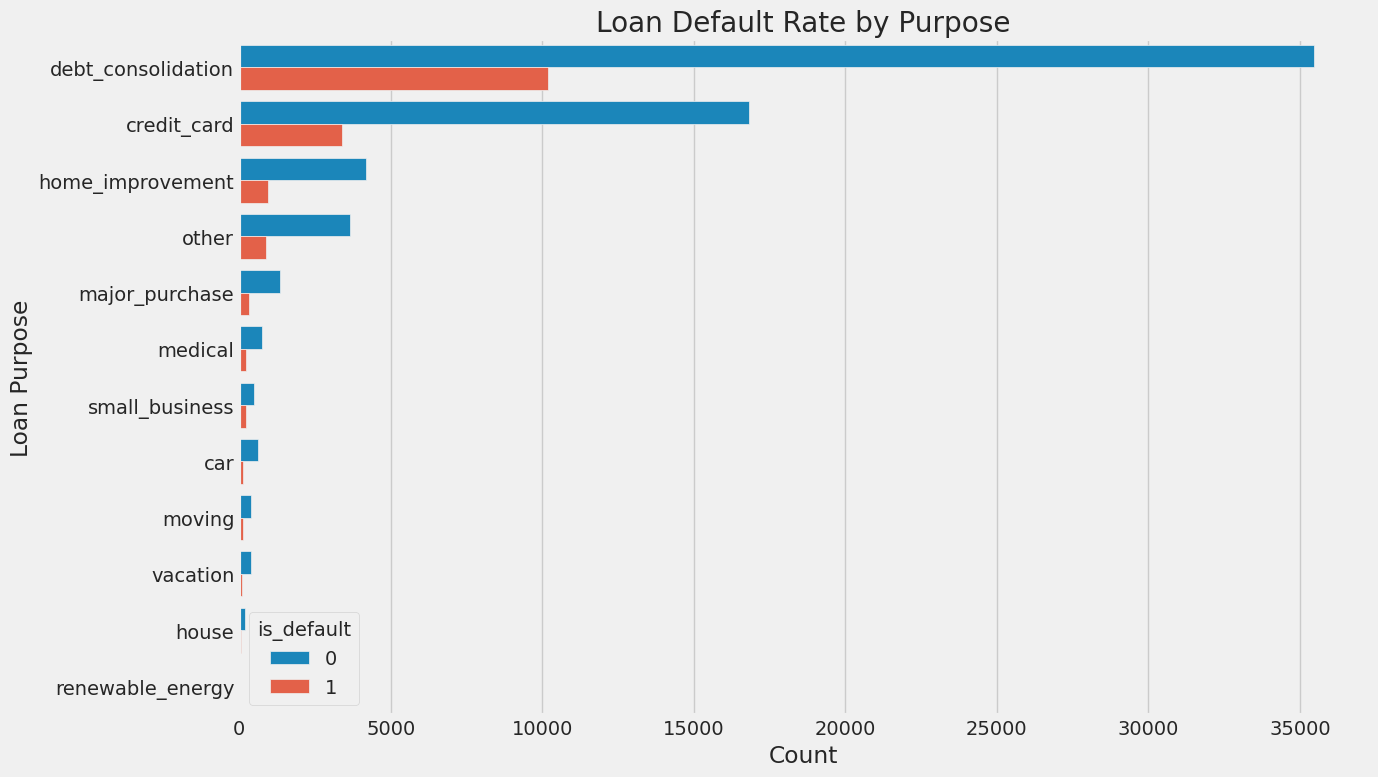

EDA Finding: Loans for 'small_business' and 'debt_consolidation' appear to have a higher number of defaults.


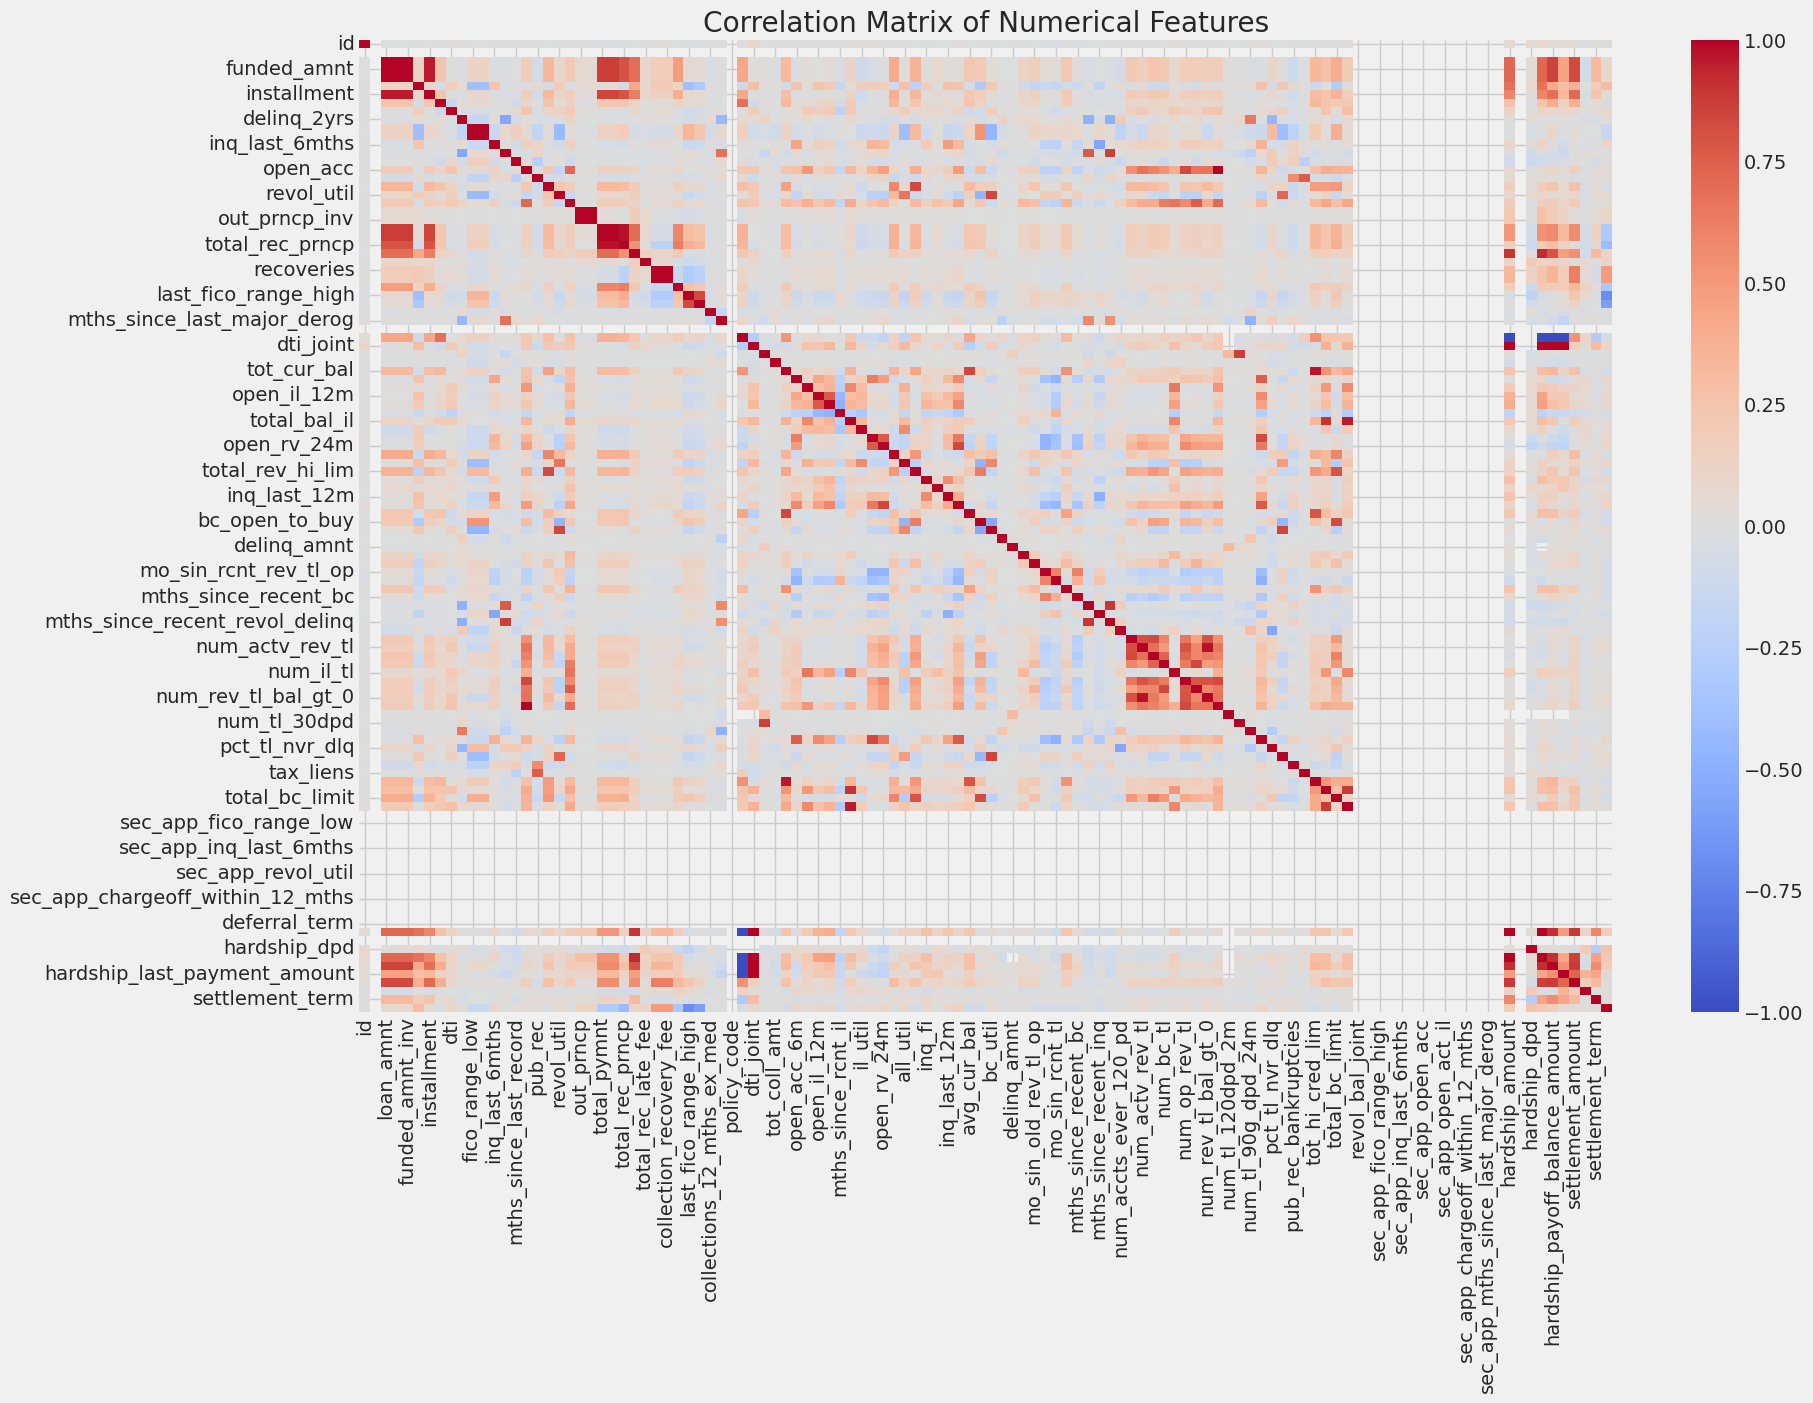


## Top 10 Features Correlated with 'is_default' ##
is_default                                    1.000000
recoveries                                    0.491587
collection_recovery_fee                       0.488959
int_rate                                      0.309338
hardship_dpd                                  0.271814
orig_projected_additional_accrued_interest    0.213063
hardship_amount                               0.194913
hardship_payoff_balance_amount                0.186435
acc_open_past_24mths                          0.138038
total_rec_late_fee                            0.125329
Name: is_default, dtype: float64


In [ ]:
# Step 1: Import Necessary Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_style('whitegrid')
plt.style.use('fivethirtyeight')

print("Libraries imported successfully.")

# Step 2: Load the Dataset
# We'll use error_bad_lines=False and warn_bad_lines=False for older pandas versions
# For newer pandas versions, these arguments might not be needed or might be replaced.
# Let's also parse the 'issue_d' as a date.
try:
    df = pd.read_csv('accepted.csv', parse_dates=['issue_d'])
except Exception as e:
    # A fallback for potential parsing issues with very large files on some systems
    df = pd.read_csv('accepted.csv')
    df['issue_d'] = pd.to_datetime(df['issue_d'], errors='coerce')

print(f"Dataset loaded successfully with {df.shape[0]} rows and {df.shape[1]} columns.")


# Step 3: Initial Data Inspection
print("\n## First 5 Rows of the Dataset ##")
print(df.head())

print("\n## Dataset Info: Columns, Data Types, Non-Null Counts ##")
df.info(verbose=False) # Use verbose=False for a concise output

print("\n## Count of Missing Values per Column (Top 15) ##")
print(df.isnull().sum().sort_values(ascending=False).head(15))


# Step 4: Define the Target Variable
# This is the most important step for our project. We need to create a binary
# target variable 'is_default' from the 'loan_status' column.

# Define what constitutes a "bad" loan
bad_loan_statuses = ['Charged Off', 'Default',
                     'Does not meet the credit policy. Status:Charged Off',
                     'Late (31-120 days)']

# Filter the DataFrame to include only 'Fully Paid' and bad loan statuses
df_filtered = df[df['loan_status'].isin(['Fully Paid'] + bad_loan_statuses)].copy()

# Create the binary target column: 1 for bad loan, 0 for good loan
df_filtered['is_default'] = df_filtered['loan_status'].apply(lambda x: 1 if x in bad_loan_statuses else 0)

print(f"\nFiltered dataset to {df_filtered.shape[0]} rows for clear default/paid outcomes.")
print("\n## Value Counts of our new Target Variable 'is_default' ##")
print(df_filtered['is_default'].value_counts())


# Step 5: Analyze the Target Variable
plt.figure(figsize=(8, 6))
sns.countplot(x='is_default', data=df_filtered)
plt.title('Distribution of Loan Defaults (Target Variable)')
plt.xlabel('Loan Status (1: Default, 0: Fully Paid)')
plt.ylabel('Count')
plt.show()
print("EDA Finding: There is a significant class imbalance. 'Fully Paid' loans far outnumber 'Default' loans.")


# Step 6: Analyze Key Features against the Target Variable

## Numerical Features ##

# Interest Rate: Does a higher interest rate correlate with default?
plt.figure(figsize=(12, 6))
# Note: 'int_rate' is likely an object/string type, e.g., '12.5%'. We need to convert it.
df_filtered['int_rate'] = df_filtered['int_rate'].astype(str).str.replace('%', '').astype(float)
sns.boxplot(x='is_default', y='int_rate', data=df_filtered)
plt.title('Interest Rate vs. Loan Default Status')
plt.xlabel('Loan Status (1: Default, 0: Fully Paid)')
plt.ylabel('Interest Rate (%)')
plt.show()
print("EDA Finding: Yes, loans that defaulted tend to have a higher interest rate.")

# Loan Amount
plt.figure(figsize=(12, 6))
sns.boxplot(x='is_default', y='loan_amnt', data=df_filtered)
plt.title('Loan Amount vs. Loan Default Status')
plt.xlabel('Loan Status (1: Default, 0: Fully Paid)')
plt.ylabel('Loan Amount ($)')
plt.show()

## Categorical Features ##

# Loan Grade: Are certain grades riskier?
plt.figure(figsize=(12, 8))
sns.countplot(x='grade', data=df_filtered, hue='is_default', order=sorted(df_filtered['grade'].unique()))
plt.title('Loan Default Rate by Grade')
plt.xlabel('Loan Grade')
plt.ylabel('Count')
plt.show()
print("EDA Finding: Lower grades (D, E, F, G) have a much higher proportion of defaults compared to higher grades (A, B).")


# Loan Purpose: Are loans for certain purposes more likely to default?
plt.figure(figsize=(14, 8))
sns.countplot(y='purpose', data=df_filtered, hue='is_default', order=df_filtered['purpose'].value_counts().index)
plt.title('Loan Default Rate by Purpose')
plt.xlabel('Count')
plt.ylabel('Loan Purpose')
plt.tight_layout()
plt.show()
print("EDA Finding: Loans for 'small_business' and 'debt_consolidation' appear to have a higher number of defaults.")


# Step 7: Correlation Heatmap for Numerical Features
plt.figure(figsize=(18, 12))
# Select only numerical columns for correlation calculation
numeric_df = df_filtered.select_dtypes(include=np.number)
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

# To see which features are most correlated with our target variable:
print("\n## Top 10 Features Correlated with 'is_default' ##")
print(corr_matrix['is_default'].sort_values(ascending=False).head(10))

In [ ]:
# The script assumes 'df_filtered' from the EDA phase is in memory.
# If not, you would first re-run the data loading and target variable creation steps.

print("Starting Phase 3: Data Preprocessing and Feature Engineering...")

# Step 1: Handling Missing Values - Dropping Columns
# First, let's identify columns with a high percentage of missing values.
missing_percentage = df_filtered.isnull().sum() / len(df_filtered) * 100
cols_to_drop = missing_percentage[missing_percentage > 30].index

print(f"\nDropping {len(cols_to_drop)} columns with more than 30% missing values.")
df_processed = df_filtered.drop(columns=cols_to_drop)

print("Columns dropped. New shape:", df_processed.shape)


# Step 2: Feature Engineering & Data Cleaning

# Feature 1: Credit History Length
# We'll calculate the length of the borrower's credit history in years.
df_processed['earliest_cr_line'] = pd.to_datetime(df_processed['earliest_cr_line'], errors='coerce')
# Calculate the difference between the loan issue date and the earliest credit line date
df_processed['credit_history_length'] = (df_processed['issue_d'] - df_processed['earliest_cr_line']).dt.days / 365.25
print("\nCreated new feature: 'credit_history_length'.")

# Feature 2: Clean 'term' column
# Convert ' 36 months' to a numerical 36
df_processed['term'] = df_processed['term'].apply(lambda s: int(s.strip().split()[0]))
print("Cleaned 'term' feature to be numerical.")

# Feature 3: Clean 'emp_length' column
# Convert employment length from string to a numerical value.
emp_length_map = {
    '< 1 year': 0,
    '1 year': 1,
    '2 years': 2,
    '3 years': 3,
    '4 years': 4,
    '5 years': 5,
    '6 years': 6,
    '7 years': 7,
    '8 years': 8,
    '9 years': 9,
    '10+ years': 10
}
df_processed['emp_length'] = df_processed['emp_length'].map(emp_length_map)
print("Cleaned 'emp_length' feature to be numerical.")


# Step 3: Feature Selection
# We will select a subset of features that are available before a loan is approved
# and are potentially predictive. We also add our newly engineered features.
# We must AVOID features that are post-funding (e.g., 'total_pymnt') as they cause data leakage.

features_to_keep = [
    'loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade',
    'emp_length', 'home_ownership', 'annual_inc', 'verification_status',
    'purpose', 'dti', 'delinq_2yrs', 'fico_range_low', 'fico_range_high',
    'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util',
    'total_acc', 'credit_history_length'
]

target = 'is_default'

# Create a new DataFrame with only the selected features and the target variable
df_model_data = df_processed[features_to_keep + [target]].copy()

print(f"\nSelected {len(features_to_keep)} features for the model.")


# Step 4: Final Cleaning of the Selected DataFrame
# We'll drop any remaining rows with missing values in our final feature set.
print("Original number of rows in model data:", len(df_model_data))
df_model_data.dropna(inplace=True)
print("Number of rows after dropping remaining NaNs:", len(df_model_data))


# Step 5: Convert Categorical Features to Dummies (One-Hot Encoding)
# Identify categorical columns to be encoded
categorical_cols = df_model_data.select_dtypes(include=['object', 'category']).columns

# The 'grade' and 'sub_grade' are ordinal, but tree-based models like XGBoost can
# handle them well with one-hot encoding, and it's a safe approach.
print(f"\nPerforming one-hot encoding on: {list(categorical_cols)}")

df_encoded = pd.get_dummies(df_model_data, columns=categorical_cols, drop_first=True)

print("Data successfully encoded. New shape:", df_encoded.shape)
print("\n## First 5 rows of the final, processed dataset ##")
print(df_encoded.head())


# Step 6: Save the Processed Data
# This is our final, clean "data mart" ready for modeling.
output_path = '/processed_loan_data.csv'
df_encoded.to_csv(output_path, index=False)

print(f"\nPreprocessing complete. Final dataset saved to '{output_path}'.")
print(f"The dataset contains {df_encoded.shape[0]} samples and {df_encoded.shape[1] - 1} features for modeling.")

Starting Phase 3: Data Preprocessing and Feature Engineering...

Dropping 58 columns with more than 30% missing values.
Columns dropped. New shape: (80975, 94)

Created new feature: 'credit_history_length'.


/tmp/ipython-input-4293478516.py:21: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_processed['earliest_cr_line'] = pd.to_datetime(df_processed['earliest_cr_line'], errors='coerce')


Cleaned 'term' feature to be numerical.
Cleaned 'emp_length' feature to be numerical.

Selected 22 features for the model.
Original number of rows in model data: 80975
Number of rows after dropping remaining NaNs: 75744

Performing one-hot encoding on: ['grade', 'sub_grade', 'home_ownership', 'verification_status', 'purpose']
Data successfully encoded. New shape: (75744, 74)

## First 5 rows of the final, processed dataset ##
   loan_amnt  term  int_rate  installment  emp_length  annual_inc    dti  \
0     3600.0    36     13.99       123.03        10.0     55000.0   5.91   
1    24700.0    36     11.99       820.28        10.0     65000.0  16.06   
2    20000.0    60     10.78       432.66        10.0     63000.0  10.78   
4    10400.0    60     22.45       289.91         3.0    104433.0  25.37   
5    11950.0    36     13.44       405.18         4.0     34000.0  10.20   

   delinq_2yrs  fico_range_low  fico_range_high  ...  \
0          0.0           675.0            679.0  ...   
1